# Lección 9: Interpretación de Modelos

Entendiendo que aprendio tu modelo.

## Configuración

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from sklearn.datasets import load_breast_cancer, fetch_california_housing
from sklearn.model_selection import train_test_split

plt.style.use('seaborn-v0_8-whitegrid')
np.random.seed(42)

## 1. Importancia por Permutación

In [2]:
data = load_breast_cancer()
X, y = data.data, data.target
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Convert numpy feature names to Python strings
feature_names = [str(f) for f in data.feature_names]

# Built-in vs. Permutation
result = permutation_importance(rf, X_test, y_test, n_repeats=10, random_state=42)

comparison = pd.DataFrame({
    'feature': feature_names,
    'impurity': rf.feature_importances_,
    'permutation': result.importances_mean,
})

top_features = comparison.sort_values('permutation', ascending=False).head(10)
print(top_features.to_string(index=False))

               feature  impurity  permutation
          mean texture  0.013591     0.003509
             mean area  0.047555     0.003509
          worst radius  0.077987     0.003509
         worst texture  0.021749     0.002632
            worst area  0.153892     0.002632
        mean concavity  0.068001     0.000877
       worst concavity  0.031802     0.000877
         mean symmetry  0.003770     0.000000
mean fractal dimension  0.003886     0.000000
          radius error  0.020139     0.000000


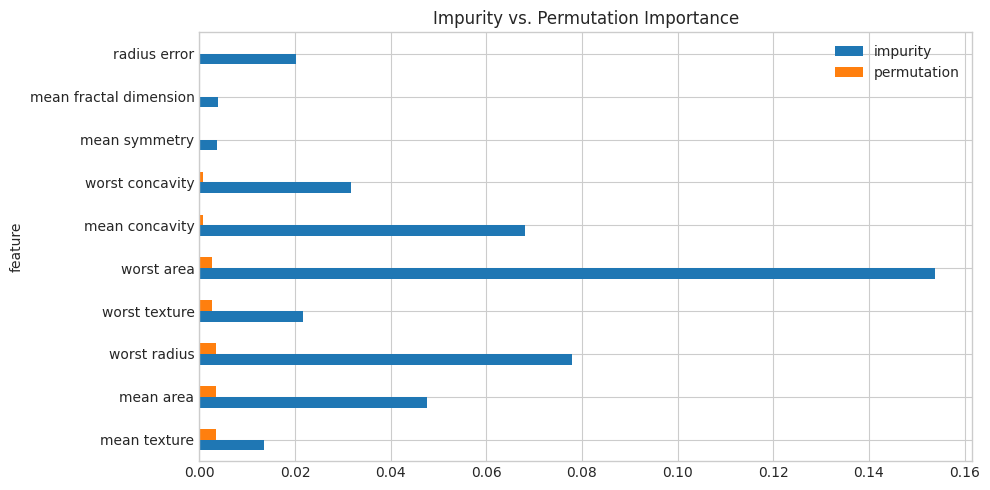

In [3]:
top_features.plot(x='feature', y=['impurity', 'permutation'], kind='barh', figsize=(10, 5))
plt.title('Impurity vs. Permutation Importance')
plt.tight_layout()
plt.show()

## 2. Gráficos de Dependencia Parcial

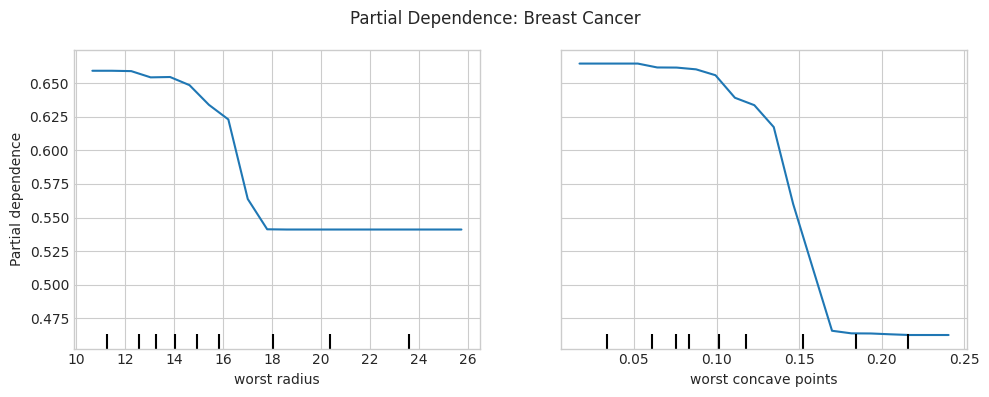

In [4]:
fig, ax = plt.subplots(figsize=(10, 4))
PartialDependenceDisplay.from_estimator(
    rf, X_test, ['worst radius', 'worst concave points'],
    feature_names=feature_names, grid_resolution=20, ax=ax
)
plt.suptitle('Partial Dependence: Breast Cancer')
plt.tight_layout()
plt.show()

## 3. PDP para California Housing

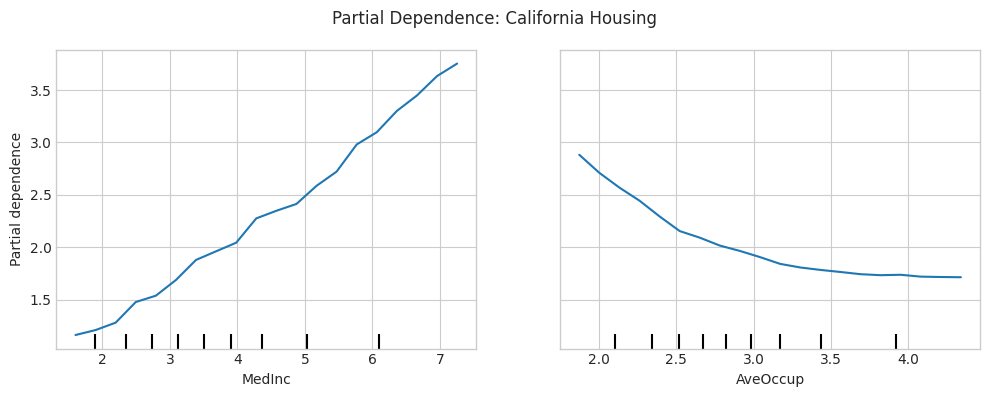

In [5]:
housing = fetch_california_housing()
X_h, y_h = housing.data, housing.target
Xh_tr, Xh_te, yh_tr, yh_te = train_test_split(X_h, y_h, test_size=0.2, random_state=42)

rf_h = RandomForestRegressor(n_estimators=100, random_state=42)
rf_h.fit(Xh_tr, yh_tr)

housing_features = [str(f) for f in housing.feature_names]

fig, ax = plt.subplots(figsize=(10, 4))
PartialDependenceDisplay.from_estimator(
    rf_h, Xh_te, ['MedInc', 'AveOccup'],
    feature_names=housing_features, grid_resolution=20, ax=ax
)
plt.suptitle('Partial Dependence: California Housing')
plt.tight_layout()
plt.show()

## 4. Importancia por Permutación con Repeticiones

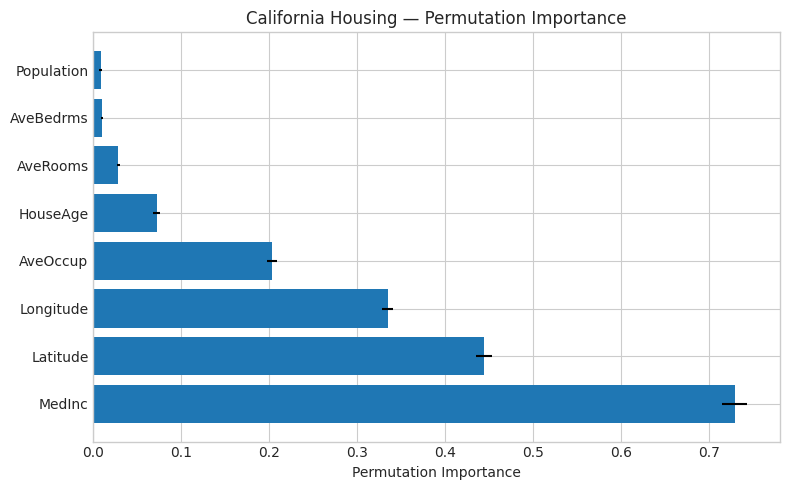

In [6]:
result_h = permutation_importance(rf_h, Xh_te, yh_te, n_repeats=10, random_state=42)

sorted_idx = result_h.importances_mean.argsort()[::-1]

plt.figure(figsize=(8, 5))
plt.barh([housing_features[i] for i in sorted_idx],
         result_h.importances_mean[sorted_idx],
         xerr=result_h.importances_std[sorted_idx])
plt.xlabel('Permutation Importance')
plt.title('California Housing — Permutation Importance')
plt.tight_layout()
plt.show()

## 5. Biotecnologia: Descubrimiento de Genes

In [7]:
n, n_g = 300, 100
X_genes = np.random.randn(n, n_g)
y_disease = (X_genes[:, 0]*0.5 + X_genes[:, 15]*0.3 - X_genes[:, 42]*0.4 > 0).astype(int)

rf_gene = RandomForestClassifier(n_estimators=100, random_state=42)
rf_gene.fit(X_genes, y_disease)

perm = permutation_importance(rf_gene, X_genes, y_disease, n_repeats=5, random_state=42)
top = np.argsort(perm.importances_mean)[::-1][:5]
print("Top genes:")
for g in top:
    print(f"  Gene {g}: importance = {perm.importances_mean[g]:.4f}")

Top genes:
  Gene 0: importance = 0.0260
  Gene 42: importance = 0.0020
  Gene 15: importance = 0.0020
  Gene 99: importance = 0.0000
  Gene 95: importance = 0.0000


## 6. Exercises

### Nivel 1
Por qué la importancia por permutación es mas confiable que la importancia basada en impureza?

### Nivel 2
Entrena RF en California Housing, calcula la importancia por permutación, grafica los 5 principales.

### Nivel 3
Las caracteristicas A y B estan correlacionadas (r=0.95). La importancia por permutación para ambas es baja. Eliminas A y B se vuelve importante. Qué está pasando?

In [8]:
# Level 2 code

## 7. Coding Challenge

Escribe `compare_importances(model, X_val, y_val, feature_names)` retornando un DataFrame de comparación.

In [9]:
def compare_importances(model, X_val, y_val, feature_names):
    impurity = model.feature_importances_
    perm = permutation_importance(model, X_val, y_val, n_repeats=10, random_state=42)
    df = pd.DataFrame({
        'feature': feature_names,
        'impurity': impurity,
        'permutation': perm.importances_mean,
        'perm_std': perm.importances_std
    }).sort_values('permutation', ascending=False)
    return df

comparison_df = compare_importances(rf, X_test, y_test, feature_names)
print(comparison_df.head(10).to_string(index=False))

               feature  impurity  permutation  perm_std
          mean texture  0.013591     0.003509  0.004297
             mean area  0.047555     0.003509  0.004297
          worst radius  0.077987     0.003509  0.004297
         worst texture  0.021749     0.002632  0.004020
            worst area  0.153892     0.002632  0.007895
        mean concavity  0.068001     0.000877  0.002632
       worst concavity  0.031802     0.000877  0.002632
         mean symmetry  0.003770     0.000000  0.000000
mean fractal dimension  0.003886     0.000000  0.000000
          radius error  0.020139     0.000000  0.000000


## Resumen

- Importancia por permutación: mezclar → medir caida de puntuación
- Dependencia parcial: como la caracteristica afecta las predicciones
- SHAP/LIME para explicaciones locales
- Siempre compara multiples métodos de importancia
- El conocimiento del dominio es esencial
- La interpretabilidad genera confianza y permite el descubrimiento